In [7]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
from matplotlib.colors import LinearSegmentedColormap
import os
import scipy.stats as stats

In [8]:
sam_mg = SAM()
sam_mg.load_data('../../Active_SAM_joined/SAM_Allen_Institute_allhypo_01272026.h5ad')

In [10]:
with open('../../parent_dict.pkl', 'rb') as f:
    parent_dict = pickle.load(f)

In [11]:
plt_df_saturn = pd.DataFrame(index = [i for i in sam_mg.adata.obs['subclass_id_label'].unique() if parent_dict[parent_dict[i]] == 'hypo'],
                      columns = ['mg','mo','cj','ac','xt','dr'])
plt_df_samap = pd.DataFrame(index = [i for i in sam_mg.adata.obs['subclass_id_label'].unique() if parent_dict[parent_dict[i]] == 'hypo'],
                      columns = ['mg','mo','cj','ac','xt','dr'])
plt_df_NT = pd.DataFrame(index = [i for i in sam_mg.adata.obs['subclass_id_label'].unique() if parent_dict[parent_dict[i]] == 'hypo'],
                      columns = ['mg','mo','cj','ac','xt','dr'])

In [58]:
fn = '../../Active_SAM_joined/SAM_MO_soupx_plus5_cleaned_03122025.h5ad'

In [59]:
sam = SAM()
sam.load_data(fn)

In [60]:
org = 'mo'

In [61]:
lsaturn_m = pd.read_csv('../../SATURN_mapping/MO_30_seeds.csv', index_col = 'barcode')

In [49]:
ind = pd.read_csv('../../Active_SAMap_Joined/CJ_MG_mapping_cleaned_03122025_0.csv')['Unnamed: 0']
lsamap_m = pd.DataFrame(index = list(ind))
for i in range(30):
    df = pd.read_csv('../../Active_SAMap_Joined/CJ_MG_mapping_cleaned_03122025_'+str(i)+'.csv', index_col = 'Unnamed: 0')
    lsamap_m = pd.concat([lsamap_m, df], axis = 1)

In [53]:
lsaturn_m

,seed_0,seed_1,seed_2,seed_3,seed_4,seed_5,seed_6,seed_7,seed_8,seed_9,...,seed_20,seed_21,seed_22,seed_23,seed_24,seed_25,seed_26,seed_27,seed_28,seed_29
barcode,,,,,,,,,,,,,,,,,,,,,
AAACCCAAGACGACTG Run 11 sample 8,085 SI-MPO-LPO Lhx8 Gaba,268 CS-PRNr-DR En1 Sox2 Gaba,272 LDT-PCG-CS Gata3 Lhx1 Gaba,059 GPe-SI Sox6 Cyp26b1 Gaba,268 CS-PRNr-DR En1 Sox2 Gaba,268 CS-PRNr-DR En1 Sox2 Gaba,274 PDTg Otp Shroom3 Gaba,197 SNr Six3 Gaba,085 SI-MPO-LPO Lhx8 Gaba,274 PDTg Otp Shroom3 Gaba,...,103 PVHd-DMH Lhx6 Gaba,195 SNr-VTA Pax5 Npas1 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,273 PDTg-PCG Pax6 Gaba,271 NI-RPO Gata3 Nr4a2 Gaba,059 GPe-SI Sox6 Cyp26b1 Gaba,059 GPe-SI Sox6 Cyp26b1 Gaba,103 PVHd-DMH Lhx6 Gaba,103 PVHd-DMH Lhx6 Gaba,197 SNr Six3 Gaba
AAACCCAAGTGCTCAT Run 11 sample 8,327 Oligo NN,027 L6b EPd Glut,327 Oligo NN,311 CBX MLI Megf11 Gaba,327 Oligo NN,337 DC NN,333 Endo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,...,327 Oligo NN,327 Oligo NN,327 Oligo NN,325 CHOR NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,338 Lymphoid NN,327 Oligo NN
AAACCCAGTCGAAACG Run 11 sample 8,126 ARH-PVp Tbx3 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,126 ARH-PVp Tbx3 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,...,129 VMH Nr5a1 Glut,126 ARH-PVp Tbx3 Glut,124 MPN-MPO-PVpo Hmx2 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,140 PMd-LHA Foxb1 Glut
AAACCCAGTCTTGAAC Run 11 sample 8,327 Oligo NN,027 L6b EPd Glut,327 Oligo NN,311 CBX MLI Megf11 Gaba,327 Oligo NN,337 DC NN,333 Endo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,...,327 Oligo NN,327 Oligo NN,327 Oligo NN,325 CHOR NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,338 Lymphoid NN,327 Oligo NN
AAACCCAGTGCCGGTT Run 11 sample 8,090 BST-MPN Six3 Nrgn Gaba,069 LSX Nkx2-1 Gaba,090 BST-MPN Six3 Nrgn Gaba,068 LSX Otx2 Gaba,069 LSX Nkx2-1 Gaba,090 BST-MPN Six3 Nrgn Gaba,070 LSX Prdm12 Slit2 Gaba,096 PVHd Gsc Gaba,090 BST-MPN Six3 Nrgn Gaba,090 BST-MPN Six3 Nrgn Gaba,...,096 PVHd Gsc Gaba,090 BST-MPN Six3 Nrgn Gaba,074 MEA-BST Lhx6 Sp9 Gaba,090 BST-MPN Six3 Nrgn Gaba,090 BST-MPN Six3 Nrgn Gaba,074 MEA-BST Lhx6 Sp9 Gaba,090 BST-MPN Six3 Nrgn Gaba,090 BST-MPN Six3 Nrgn Gaba,090 BST-MPN Six3 Nrgn Gaba,090 BST-MPN Six3 Nrgn Gaba
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTTCCACAGCG Run 11 sample 7,092 TMv-PMv Tbx3 Hist-Gaba,092 TMv-PMv Tbx3 Hist-Gaba,092 TMv-PMv Tbx3 Hist-Gaba,125 DMH Hmx2 Glut,092 TMv-PMv Tbx3 Hist-Gaba,126 ARH-PVp Tbx3 Glut,125 DMH Hmx2 Glut,092 TMv-PMv Tbx3 Hist-Gaba,092 TMv-PMv Tbx3 Hist-Gaba,125 DMH Hmx2 Glut,...,125 DMH Hmx2 Glut,125 DMH Hmx2 Glut,130 LHA Pmch Glut,125 DMH Hmx2 Glut,125 DMH Hmx2 Glut,092 TMv-PMv Tbx3 Hist-Gaba,125 DMH Hmx2 Glut,125 DMH Hmx2 Glut,125 DMH Hmx2 Glut,092 TMv-PMv Tbx3 Hist-Gaba
TTTGGTTTCCATCAGA Run 11 sample 7,132 AHN-RCH-LHA Otp Fezf1 Glut,122 LHA-MEA Otp Glut,131 LHA-AHN-PVH Otp Trh Glut,131 LHA-AHN-PVH Otp Trh Glut,143 MM-ant Foxb1 Glut,131 LHA-AHN-PVH Otp Trh Glut,122 LHA-MEA Otp Glut,121 MEA-BST Otp Zic2 Glut,131 LHA-AHN-PVH Otp Trh Glut,122 LHA-MEA Otp Glut,...,131 LHA-AHN-PVH Otp Trh Glut,131 LHA-AHN-PVH Otp Trh Glut,132 AHN-RCH-LHA Otp Fezf1 Glut,122 LHA-MEA Otp Glut,131 LHA-AHN-PVH Otp Trh Glut,131 LHA-AHN-PVH Otp Trh Glut,122 LHA-MEA Otp Glut,131 LHA-AHN-PVH Otp Trh Glut,122 LHA-MEA Otp Glut,243 PGRN-PARN-MDRN Hoxb5 Glut
TTTGGTTTCGGTGCAC Run 11 sample 7,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,...,113 MEA-COA-BMA Ccdc42 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut


In [54]:
lsamap_m

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
AAACCCAAGACGACTG Run 11 sample 8,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,...,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba,085 SI-MPO-LPO Lhx8 Gaba
AAACCCAAGTGCTCAT Run 11 sample 8,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,...,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN
AAACCCAGTCGAAACG Run 11 sample 8,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,124 MPN-MPO-PVpo Hmx2 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,...,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut
AAACCCAGTCTTGAAC Run 11 sample 8,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,...,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN,327 Oligo NN
AAACCCAGTGCCGGTT Run 11 sample 8,090 BST-MPN Six3 Nrgn Gaba,090 BST-MPN Six3 Nrgn Gaba,090 BST-MPN Six3 Nrgn Gaba,090 BST-MPN Six3 Nrgn Gaba,090 BST-MPN Six3 Nrgn Gaba,090 BST-MPN Six3 Nrgn Gaba,090 BST-MPN Six3 Nrgn Gaba,090 BST-MPN Six3 Nrgn Gaba,090 BST-MPN Six3 Nrgn Gaba,090 BST-MPN Six3 Nrgn Gaba,...,090 BST-MPN Six3 Nrgn Gaba,090 BST-MPN Six3 Nrgn Gaba,090 BST-MPN Six3 Nrgn Gaba,090 BST-MPN Six3 Nrgn Gaba,090 BST-MPN Six3 Nrgn Gaba,090 BST-MPN Six3 Nrgn Gaba,090 BST-MPN Six3 Nrgn Gaba,090 BST-MPN Six3 Nrgn Gaba,090 BST-MPN Six3 Nrgn Gaba,090 BST-MPN Six3 Nrgn Gaba
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTTCCACAGCG Run 11 sample 7,125 DMH Hmx2 Glut,125 DMH Hmx2 Glut,125 DMH Hmx2 Glut,125 DMH Hmx2 Glut,125 DMH Hmx2 Glut,125 DMH Hmx2 Glut,125 DMH Hmx2 Glut,125 DMH Hmx2 Glut,125 DMH Hmx2 Glut,125 DMH Hmx2 Glut,...,125 DMH Hmx2 Glut,125 DMH Hmx2 Glut,125 DMH Hmx2 Glut,125 DMH Hmx2 Glut,125 DMH Hmx2 Glut,125 DMH Hmx2 Glut,125 DMH Hmx2 Glut,125 DMH Hmx2 Glut,125 DMH Hmx2 Glut,125 DMH Hmx2 Glut
TTTGGTTTCCATCAGA Run 11 sample 7,132 AHN-RCH-LHA Otp Fezf1 Glut,132 AHN-RCH-LHA Otp Fezf1 Glut,132 AHN-RCH-LHA Otp Fezf1 Glut,132 AHN-RCH-LHA Otp Fezf1 Glut,132 AHN-RCH-LHA Otp Fezf1 Glut,132 AHN-RCH-LHA Otp Fezf1 Glut,132 AHN-RCH-LHA Otp Fezf1 Glut,132 AHN-RCH-LHA Otp Fezf1 Glut,132 AHN-RCH-LHA Otp Fezf1 Glut,132 AHN-RCH-LHA Otp Fezf1 Glut,...,132 AHN-RCH-LHA Otp Fezf1 Glut,132 AHN-RCH-LHA Otp Fezf1 Glut,132 AHN-RCH-LHA Otp Fezf1 Glut,132 AHN-RCH-LHA Otp Fezf1 Glut,132 AHN-RCH-LHA Otp Fezf1 Glut,132 AHN-RCH-LHA Otp Fezf1 Glut,132 AHN-RCH-LHA Otp Fezf1 Glut,132 AHN-RCH-LHA Otp Fezf1 Glut,132 AHN-RCH-LHA Otp Fezf1 Glut,132 AHN-RCH-LHA Otp Fezf1 Glut
TTTGGTTTCGGTGCAC Run 11 sample 7,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,...,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut,129 VMH Nr5a1 Glut
TTTGTTGAGGAATTAC Run 11 sample 7,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STR

In [64]:
meta_folder = '../../Active_SAMap_Joined/MO_metadata/'

In [65]:
mn = os.listdir('../../Active_SAMap_Joined/MO_metadata/')

In [66]:
pd.read_csv(meta_folder + mn[3])

,Unnamed: 0,orig.ident,nCount_RNA,nFeature_RNA,n_counts,n_genes,key,eq_subclass_nounlabeled,leiden_removal,SCT_snn_res.5,leiden_clusters,subclass_id_label_mapping,subclass_id_label_lc
0,AAACCCATCTCAAAGC,MO,11772.0,3844,11772.0,3844,Run12_sample1,mo_9,35,15,86,Unlabeled,86
1,AAACGAACAGCACGAA,MO,4877.0,2561,4877.0,2561,Run12_sample1,mo_5,39,105,240,Unlabeled,240
2,AAACGAAGTCGGCACT,MO,5221.0,2859,5221.0,2859,Run12_sample1,108 ARH-PVp Tbx3 Gaba,35,14,16,108 ARH-PVp Tbx3 Gaba,16
3,AAACGAATCCACCCTA,MO,7922.0,3360,7922.0,3360,Run12_sample1,mo_2,78,87,527,Unlabeled,527
4,AAACGAATCCCAGCGA,MO,7020.0,3204,7020.0,3204,Run12_sample1,128 VMH Fezf1 Glut,2,16,333,128 VMH Fezf1 Glut,333
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75325,TTTGTTGGTACTAACC,MO,5496.0,2569,5496.0,2569,Run12_sample12,057 NDB-SI-MA-STRv Lhx8 Gaba,8,26,156,057 NDB-SI-MA-STRv Lhx8 Gaba,156
75326,TTTGTTGGTCACAATC-1,MO,2974.0,1804,2974.0,1804,Run12_sample12,089 PVR Six3 Sox3 Gaba,11,52,119,089 PVR Six3 Sox3 Gaba,119
75327,TTTGTTGTCCAACCAA,MO,5601.0,2608,5601.0,2608,Run12_sample12,mo_9,5,56,265,Unlabeled,265
75328,TTTGTTGTCCCTGTTG,MO,6209.0,2759,6209.0,2759,Run12_sample12,mo_3,1,33,522,Unlabeled,522


In [67]:
test = pd.read_csv(meta_folder + mn[0])['subclass_id_label_mapping']

In [68]:
barcodes = pd.read_csv(meta_folder + mn[0])['Unnamed: 0']

In [69]:
raw_lc = pd.read_csv(meta_folder + mn[0])['subclass_id_label_lc']

In [70]:
df_lc = pd.DataFrame(data = list(raw_lc), index = list(barcodes), columns = ['raw_lc'])

In [71]:
mode_df = pd.DataFrame(index = [a for a in range(len(test))], columns = [b for b in range(len(mn))])
for j in range(len(mn)):
    print(mn[j])
    dat = list(pd.read_csv(meta_folder + mn[j])['subclass_id_label_lc'])
    mode_df.loc[:,j] = dat

MO_metadata_soupxplus5_cleaned_03122025_subclass_250_22.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_8.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_17.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_11.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_18.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_19.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_14.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_15.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_7.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_25.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_28.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_29.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_16.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_13.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_24.csv
MO_metadata_soupxplus5_cleaned_03122025_subclass_250_21.csv
MO_metadata_soupxplus5_cleaned_03122025_su

In [72]:
fin = []
for item in mode_df.columns:
    fin.append(mode_df.loc[10000,item])

In [73]:
stats.mode(fin)

ModeResult(mode=array([62]), count=array([30]))

In [74]:
lsamap_mv = pd.DataFrame(index = [a for a in barcodes], columns = [b for b in range(len(mn))])
for j in range(len(mn)):
    dat = list(pd.read_csv(meta_folder + mn[j])['subclass_id_label_mapping'])
    lsamap_mv.loc[:,j] = dat

In [75]:
lsamap_m = lsamap_mv

In [76]:
lsamap_m

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
AAACCCATCTCAAAGC,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,...,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled
AAACGAACAGCACGAA,124 MPN-MPO-PVpo Hmx2 Glut,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,124 MPN-MPO-PVpo Hmx2 Glut,Unlabeled,124 MPN-MPO-PVpo Hmx2 Glut,Unlabeled,...,Unlabeled,124 MPN-MPO-PVpo Hmx2 Glut,Unlabeled,Unlabeled,Unlabeled,Unlabeled,124 MPN-MPO-PVpo Hmx2 Glut,Unlabeled,Unlabeled,Unlabeled
AAACGAAGTCGGCACT,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,...,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba
AAACGAATCCACCCTA,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,...,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled
AAACGAATCCCAGCGA,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,...,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGGTACTAACC,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,...,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba
TTTGTTGGTCACAATC-1,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,...,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba
TTTGTTGTCCAACCAA,107 DMH Hmx2 Gaba,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,107 DMH Hmx2 Gaba,...,107 DMH Hmx2 Gaba,Unlabeled,Unlabeled,Unlabeled,Unlabeled,107 DMH Hmx2 Gaba,Unlabeled,Unlabeled,Unlabeled,Unlabeled
TTTGTTGTCCCTGTTG,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,...,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled


In [77]:
sam.adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_counts', 'n_genes',
       'key', 'subclass_id_label_mapping', 'subclass_id_label_lc',
       'leiden_clusters', 'subclass_id_label_mapping_nounlabeled',
       'neurotransmitter', 'region_label', 'subclass_id_label_reduced_mapping',
       'subclass_id_label_reduced_lc',
       'subclass_id_label_reduced_mapping_nounlabeled',
       'leiden_clusters_formarkers', 'leiden_removal', 'nCount_SCT',
       'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5',
       'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac',
       'eq_subclass_nounlabeled', 'NN', 'ss_subclass',
       'ss_subclass_nounlabeled', 'ss_subclass_nounlabeled_03102026',
       'ss_subclass_nounlabeled_03102026_crossed', 'neurotransmitter_v2'],
      dtype='object')

In [52]:
lsamap_m

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
AAACCCATCTCAAAGC,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,...,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled
AAACGAACAGCACGAA,124 MPN-MPO-PVpo Hmx2 Glut,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,124 MPN-MPO-PVpo Hmx2 Glut,Unlabeled,124 MPN-MPO-PVpo Hmx2 Glut,Unlabeled,...,Unlabeled,124 MPN-MPO-PVpo Hmx2 Glut,Unlabeled,Unlabeled,Unlabeled,Unlabeled,124 MPN-MPO-PVpo Hmx2 Glut,Unlabeled,Unlabeled,Unlabeled
AAACGAAGTCGGCACT,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,...,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba,108 ARH-PVp Tbx3 Gaba
AAACGAATCCACCCTA,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,...,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled
AAACGAATCCCAGCGA,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,...,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut,128 VMH Fezf1 Glut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGGTACTAACC,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,...,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba,057 NDB-SI-MA-STRv Lhx8 Gaba
TTTGTTGGTCACAATC-1,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,...,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba,089 PVR Six3 Sox3 Gaba
TTTGTTGTCCAACCAA,107 DMH Hmx2 Gaba,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,107 DMH Hmx2 Gaba,...,107 DMH Hmx2 Gaba,Unlabeled,Unlabeled,Unlabeled,Unlabeled,107 DMH Hmx2 Gaba,Unlabeled,Unlabeled,Unlabeled,Unlabeled
TTTGTTGTCCCTGTTG,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,...,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled,Unlabeled


In [78]:
level = 'ss_subclass'
for item in plt_df_saturn.index:
    if item in sam.adata.obs[level].unique():
        obs_names = sam.adata.obs_names[sam.adata.obs[level] == item]
        samap_seeds = 0
        saturn_seeds = 0
        for seed in lsamap_m.columns:
            if stats.mode(lsamap_m.loc[obs_names,seed]).mode[0] == item:
                samap_seeds += 1
            if stats.mode(lsaturn_m.loc[obs_names,'seed_' + str(seed)]).mode[0] == item:
                saturn_seeds += 1
        plt_df_saturn.loc[item,org] = saturn_seeds/30
        plt_df_samap.loc[item,org] = samap_seeds/30
    else:
        plt_df_saturn.loc[item,org] = 0
        plt_df_samap.loc[item,org] = 0

In [79]:
for item in plt_df_saturn.index:
    plt_df_NT.loc[item,'mg'] = item.split(' ')[-1]

In [80]:
plt_df_saturn

,mg,mo,cj,ac,xt,dr
078 SI-MA-ACB Ebf1 Bnc2 Gaba,NaN,0.766667,0,0,0,0
079 CEA-BST Six3 Cyp26b1 Gaba,NaN,1.0,0,1.0,0.633333,0
080 CEA-AAA-BST Six3 Sp9 Gaba,NaN,0.866667,0,0,0,0
104 TU-ARH Otp Six6 Gaba,NaN,1.0,0.3,0.433333,0.9,0
101 ZI Pax6 Gaba,NaN,0.0,0.5,0.633333,0.3,0
...,...,...,...,...,...,...
127 DMH-LHA Vgll2 Glut,NaN,1.0,0.9,0.966667,0.2,0
143 MM-ant Foxb1 Glut,NaN,1.0,0,0,0.066667,0
121 MEA-BST Otp Zic2 Glut,NaN,0.833333,0,0,0,0
110 BST-po Iigp1 Glut,NaN,0,0,0,0,0


In [81]:
plt_df_samap

,mg,mo,cj,ac,xt,dr
078 SI-MA-ACB Ebf1 Bnc2 Gaba,NaN,1.0,0,0,0,0
079 CEA-BST Six3 Cyp26b1 Gaba,NaN,1.0,0,1.0,1.0,0
080 CEA-AAA-BST Six3 Sp9 Gaba,NaN,1.0,0,0,0,0
104 TU-ARH Otp Six6 Gaba,NaN,1.0,1.0,1.0,1.0,0
101 ZI Pax6 Gaba,NaN,1.0,1.0,1.0,1.0,0
...,...,...,...,...,...,...
127 DMH-LHA Vgll2 Glut,NaN,1.0,1.0,1.0,1.0,0
143 MM-ant Foxb1 Glut,NaN,1.0,0,0,0.533333,0
121 MEA-BST Otp Zic2 Glut,NaN,1.0,0,0,0,0
110 BST-po Iigp1 Glut,NaN,0,0,0,0,0


In [82]:
plt_df_samap = plt_df_samap.loc[:,['mg','mo','cj','ac','xt','dr']]

In [83]:
index_sort = list(plt_df_samap.index)
index_sort.sort()

In [84]:
plt_df_saturn = plt_df_saturn.astype(float)
plt_df_samap = plt_df_samap.astype(float)

In [85]:
plt_df_saturn = plt_df_saturn.reindex(index_sort)
plt_df_samap = plt_df_samap.reindex(index_sort)

In [86]:
plt_df_saturn.index

Index(['066 NDB-SI-ant Prdm12 Gaba', '073 MEA-BST Sox6 Gaba',
       '074 MEA-BST Lhx6 Sp9 Gaba', '075 MEA-BST Lhx6 Nr2e1 Gaba',
       '076 MEA-BST Lhx6 Nfib Gaba', '077 CEA-BST Gal Avp Gaba',
       '078 SI-MA-ACB Ebf1 Bnc2 Gaba', '079 CEA-BST Six3 Cyp26b1 Gaba',
       '080 CEA-AAA-BST Six3 Sp9 Gaba', '081 ACB-BST-FS D1 Gaba',
       '082 CEA-BST Ebf1 Pdyn Gaba', '083 CEA-BST Rai14 Pdyn Crh Gaba',
       '084 BST-SI-AAA Six3 Slc22a3 Gaba', '085 SI-MPO-LPO Lhx8 Gaba',
       '086 MPO-ADP Lhx8 Gaba', '087 MPN-MPO-LPO Lhx6 Zfhx3 Gaba',
       '088 BST Tac2 Gaba', '089 PVR Six3 Sox3 Gaba',
       '090 BST-MPN Six3 Nrgn Gaba', '091 ARH-PVi Six6 Dopa-Gaba',
       '092 TMv-PMv Tbx3 Hist-Gaba', '093 RT-ZI Gnb3 Gaba',
       '094 SCH Six6 Cdc14a Gaba', '095 DMH Prdm13 Gaba', '096 PVHd Gsc Gaba',
       '097 PVHd-SBPV Six3 Prox1 Gaba', '098 AHN-SBPV-PVHd Pdrm12 Gaba',
       '099 SBPV-PVa Six6 Satb2 Gaba', '100 AHN Onecut3 Gaba',
       '101 ZI Pax6 Gaba', '102 DMH-LHA Gsx1 Gaba', '103 PVHd-

In [87]:
my_cmap = matplotlib.cm.get_cmap("Blues").copy()
my_cmap.set_under('grey')

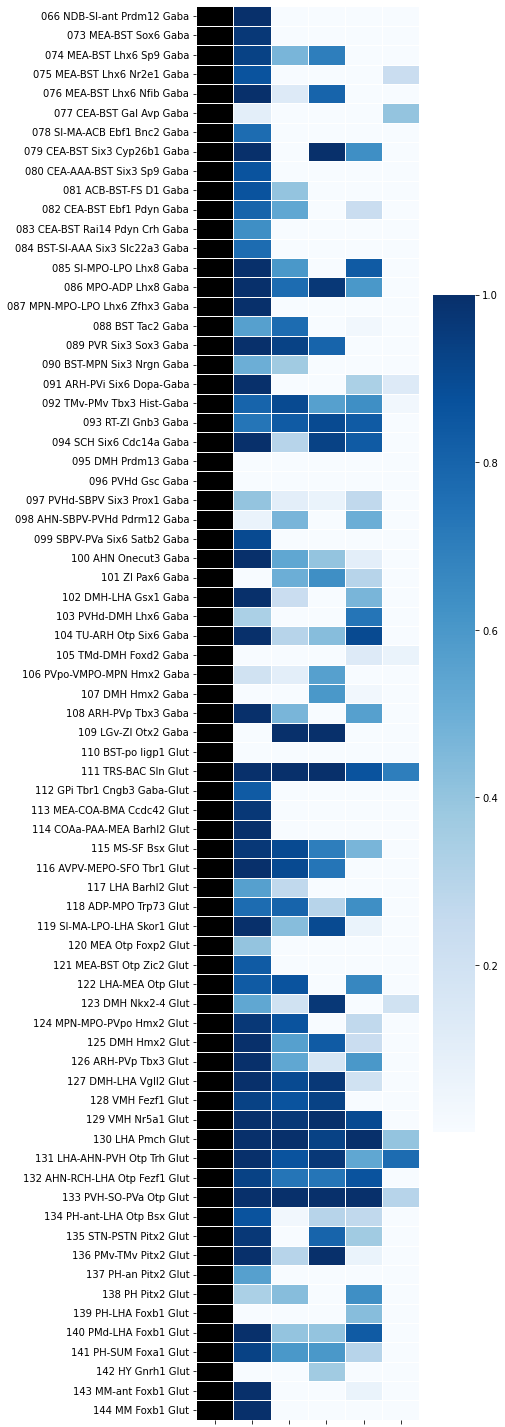

In [89]:
plt.figure(figsize=(5, 26))
ax = sns.heatmap(plt_df_saturn,vmin = .001,cmap = 'Blues',linewidth = .5)
ax.set_facecolor('black')
ax.set(xticklabels= [])
plt.savefig('../../Figures/Figures_07242026/Mapped_CT_mousefrac_saturn_Heatmap_boot_07202026.svg')
plt.savefig('../../Figures/Figures_07242026/mapped_CT_mousefrac_saturn_Heatmap_boot_07202026.png', bbox_inches = 'tight',dpi = 300)
plt.savefig('../../Figures/Figures_07242026/Mapped_CT_mousefrac_saturn_Heatmap_boot_07202026.pdf')

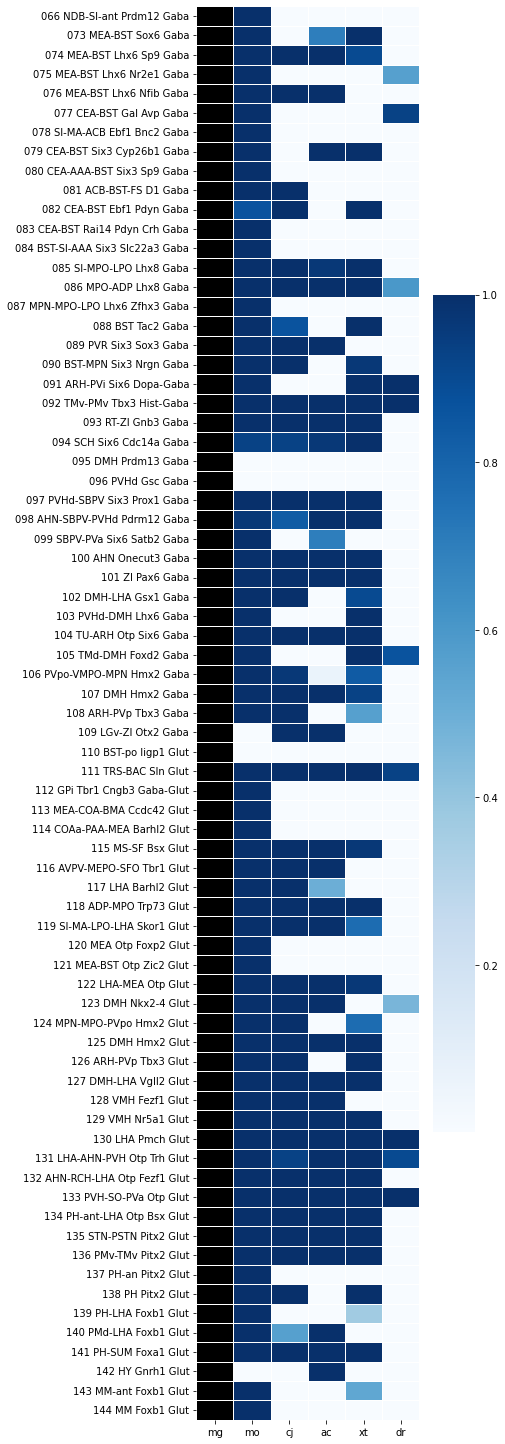

In [90]:
plt.figure(figsize=(5, 26),facecolor='white')
ax = sns.heatmap(plt_df_samap, vmin = 0.001, cmap = 'Blues',linewidth = .5)
ax.set_facecolor('black')
#ax.set(xticklabels= [])
#plt.figure(facecolor='white')
plt.savefig('../../Figures/Figures_07242026/Mapped_CT_mousefrac_samap_Heatmap_boot_07202026.svg')
plt.savefig('../../Figures/Figures_07242026/mapped_CT_mousefrac_samap_Heatmap_boot_07202026.png', bbox_inches = 'tight',dpi = 300)
plt.savefig('../../Figures/Figures_07242026/Mapped_CT_mousefrac_samap_Heatmap_boot_07202026.pdf')

In [33]:
plt_df_samap = plt_df_samap.loc[['095 DMH Prdm13 Gaba','096 PVHd Gsc Gaba','084 BST-SI-AAA Six3 Slc22a3 Gaba', '087 MPN-MPO-LPO Lhx6 Zfhx3 Gaba',
       '137 PH-an Pitx2 Glut', '144 MM Foxb1 Glut',
       '076 MEA-BST Lhx6 Nfib Gaba', '116 AVPV-MEPO-SFO Tbr1 Glut',
       '117 LHA Barhl2 Glut', '123 DMH Nkx2-4 Glut', 'cj_xt_2', 'cj_xt_3',
       'cj_xt_4', 'cj_xt_6', 'cj_xt_dr_1', 'cj_ac_xt_dr_1', 'cj_ac_xt_dr_3',
       'cj_xt_dr_2', 'cj_xt_dr_3', 'cj_ac_1', 'cj_xt_5', 'cj_ac_xt_1',
       'xt_dr_1', 'cj_ac_xt_dr_2', 'cj_ac_xt_dr_4'],:]

In [32]:
plt_df_samap.index

Index(['084 BST-SI-AAA Six3 Slc22a3 Gaba', '087 MPN-MPO-LPO Lhx6 Zfhx3 Gaba',
       '137 PH-an Pitx2 Glut', '144 MM Foxb1 Glut',
       '076 MEA-BST Lhx6 Nfib Gaba', '116 AVPV-MEPO-SFO Tbr1 Glut',
       '117 LHA Barhl2 Glut', '123 DMH Nkx2-4 Glut', 'cj_xt_2', 'cj_xt_3',
       'cj_xt_4', 'cj_xt_6', 'cj_xt_dr_1', 'cj_ac_xt_dr_1', 'cj_ac_xt_dr_3',
       'cj_xt_dr_2', 'cj_xt_dr_3', 'cj_ac_1', 'cj_xt_5', 'cj_ac_xt_1',
       'xt_dr_1', 'cj_ac_xt_dr_2', 'cj_ac_xt_dr_4', '095 DMH Prdm13 Gaba',
       '096 PVHd Gsc Gaba'],
      dtype='object')

In [83]:
plt_df_saturn.to_csv('SATURN_mousemapping_allorgs_06252026.csv')
plt_df_samap.to_csv('SAMAP_mousemapping_allorgs_06252026.csv')

In [3]:
plt_df_samap = pd.read_csv('Nonmammal_mapping_SAMap_04122026.csv', index_col = 'Unnamed: 0')
#plt_df_saturn = pd.read_csv('SATURN_mousemapping_allorgs_06162025.csv', index_col = 'Unnamed: 0')

In [4]:
plt_df_NT = pd.read_csv('Nonmammal_mapping_NT_04122026.csv', index_col = 'Unnamed: 0')

In [39]:
plt_df_NT.loc['095 DMH Prdm13 Gaba',:] = ['Gaba',np.nan,np.nan,np.nan,np.nan,np.nan]
plt_df_NT.loc['096 PVHd Gsc Gaba',:] = ['Gaba',np.nan,np.nan,np.nan,np.nan,np.nan]

In [40]:
plt_df_NT = plt_df_NT.loc[['095 DMH Prdm13 Gaba','096 PVHd Gsc Gaba','084 BST-SI-AAA Six3 Slc22a3 Gaba', '087 MPN-MPO-LPO Lhx6 Zfhx3 Gaba',
       '137 PH-an Pitx2 Glut', '144 MM Foxb1 Glut',
       '076 MEA-BST Lhx6 Nfib Gaba', '116 AVPV-MEPO-SFO Tbr1 Glut',
       '117 LHA Barhl2 Glut', '123 DMH Nkx2-4 Glut', 'cj_xt_2', 'cj_xt_3',
       'cj_xt_4', 'cj_xt_6', 'cj_xt_dr_1', 'cj_ac_xt_dr_1', 'cj_ac_xt_dr_3',
       'cj_xt_dr_2', 'cj_xt_dr_3', 'cj_ac_1', 'cj_xt_5', 'cj_ac_xt_1',
       'xt_dr_1', 'cj_ac_xt_dr_2', 'cj_ac_xt_dr_4'],:]

In [41]:
nt_mapping = {'Gaba-Chol':1,
             'Chol':1,
             'Glut-Chol':1,
             'Glut-Gaba-Dopa':2,
             'Gaba-Dopa':2,
             'Dopa-Gaba':2,
             'Glut-Dopa':2,
             'Dopa':2,
             'Gly':3,
             'Hist':4,
             'Gaba':5,
             'Glut':6,
             'Gaba-Glut':7,
             'Glut-Gaba':7,
             'Gaba-Gly':3,
             'Glut-Gly': 3,
             'Glut-Gaba-Gly':3,
             'Gaba-Hist':4,
             'Hist-Gaba':4,
             'Nora':8,
             'Gaba-Sert':9,
             'Glut-Sert':9,
             'unclear':10,
             'Chol-Gly':11,
             'Sert':9,
             'Glut-Sert-Gly':12,
             'Gaba-Dopa-Sert':13,
             'Glut-Gaba-Hist':4,
             'Glut-Gaba-Sert-Hist':4}

In [42]:
nt_mapping

{'Gaba-Chol': 1,
 'Chol': 1,
 'Glut-Chol': 1,
 'Glut-Gaba-Dopa': 2,
 'Gaba-Dopa': 2,
 'Dopa-Gaba': 2,
 'Glut-Dopa': 2,
 'Dopa': 2,
 'Gly': 3,
 'Hist': 4,
 'Gaba': 5,
 'Glut': 6,
 'Gaba-Glut': 7,
 'Glut-Gaba': 7,
 'Gaba-Gly': 3,
 'Glut-Gly': 3,
 'Glut-Gaba-Gly': 3,
 'Gaba-Hist': 4,
 'Hist-Gaba': 4,
 'Nora': 8,
 'Gaba-Sert': 9,
 'Glut-Sert': 9,
 'unclear': 10,
 'Chol-Gly': 11,
 'Sert': 9,
 'Glut-Sert-Gly': 12,
 'Gaba-Dopa-Sert': 13,
 'Glut-Gaba-Hist': 4,
 'Glut-Gaba-Sert-Hist': 4}

In [18]:
plt_df_NT = plt_df_NT.reindex(index_sort)

NameError: name 'index_sort' is not defined

In [43]:
NT_df_numeric = plt_df_NT.replace(nt_mapping)

In [44]:
NT_df_numeric = NT_df_numeric.reindex(index_sort)

NameError: name 'index_sort' is not defined

In [45]:
custom_colors = ['#73E785','#FCF04B','#820E57','#FF7621','#FF3358','#2B93DF','#0A9964','#03EDFF','#4f2e91ff','black','pink','salmon','maroon','goldenrod']

In [46]:
custom_cmap = LinearSegmentedColormap.from_list('Custom', custom_colors, len(custom_colors))

In [47]:
NT_df_numeric

,mg,mo,cj,ac,xt,dr
095 DMH Prdm13 Gaba,5.0,NaN,NaN,NaN,NaN,NaN
096 PVHd Gsc Gaba,5.0,NaN,NaN,NaN,NaN,NaN
084 BST-SI-AAA Six3 Slc22a3 Gaba,5.0,5.0,NaN,NaN,NaN,NaN
087 MPN-MPO-LPO Lhx6 Zfhx3 Gaba,5.0,5.0,NaN,NaN,NaN,NaN
137 PH-an Pitx2 Glut,6.0,6.0,NaN,NaN,NaN,NaN
144 MM Foxb1 Glut,6.0,6.0,NaN,NaN,NaN,NaN
076 MEA-BST Lhx6 Nfib Gaba,5.0,5.0,5.0,5.0,NaN,NaN
116 AVPV-MEPO-SFO Tbr1 Glut,6.0,6.0,6.0,6.0,NaN,NaN
117 LHA Barhl2 Glut,6.0,6.0,6.0,6.0,NaN,NaN
123 DMH Nkx2-4 Glut,6.0,6.0,6.0,6.0,NaN,NaN


In [48]:
NT_df_numeric = NT_df_numeric[NT_df_numeric.index != 'cj_dr_1']

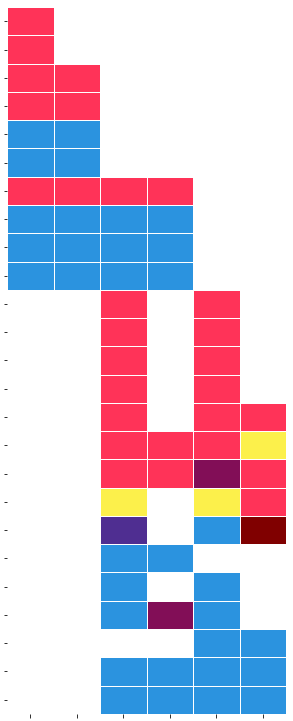

In [50]:
plt.figure(figsize=(5, 13))
ax = sns.heatmap(NT_df_numeric,cmap=custom_cmap, vmax = 14, vmin = 1, cbar = False, linewidth = .5)
ax.set(yticklabels= [])
ax.set(xticklabels= [])
plt.savefig('Figures/Figures_05222026/Nonmam_mapping_NT_05212026.svg')
plt.savefig('Figures/Figures_05222026/Nonmam_mapping_NT_05212026.png')

In [137]:
NT_df_numeric.to_csv('NT_mapping_allorgs_06162025.csv')

In [ ]:
#Numcells plotting

In [5]:
df = pd.read_csv('Allen_Institute_Numcells_RegionHY_04072026.csv')

In [8]:
HYPO = [i for i in df['cell_type'].unique() if parent_dict[parent_dict[i]] == 'hypo']

In [18]:
dfhypo = df[df['cell_type'].isin(HYPO)]

In [23]:
dfhypo = dfhypo.sort_values('cell_type')

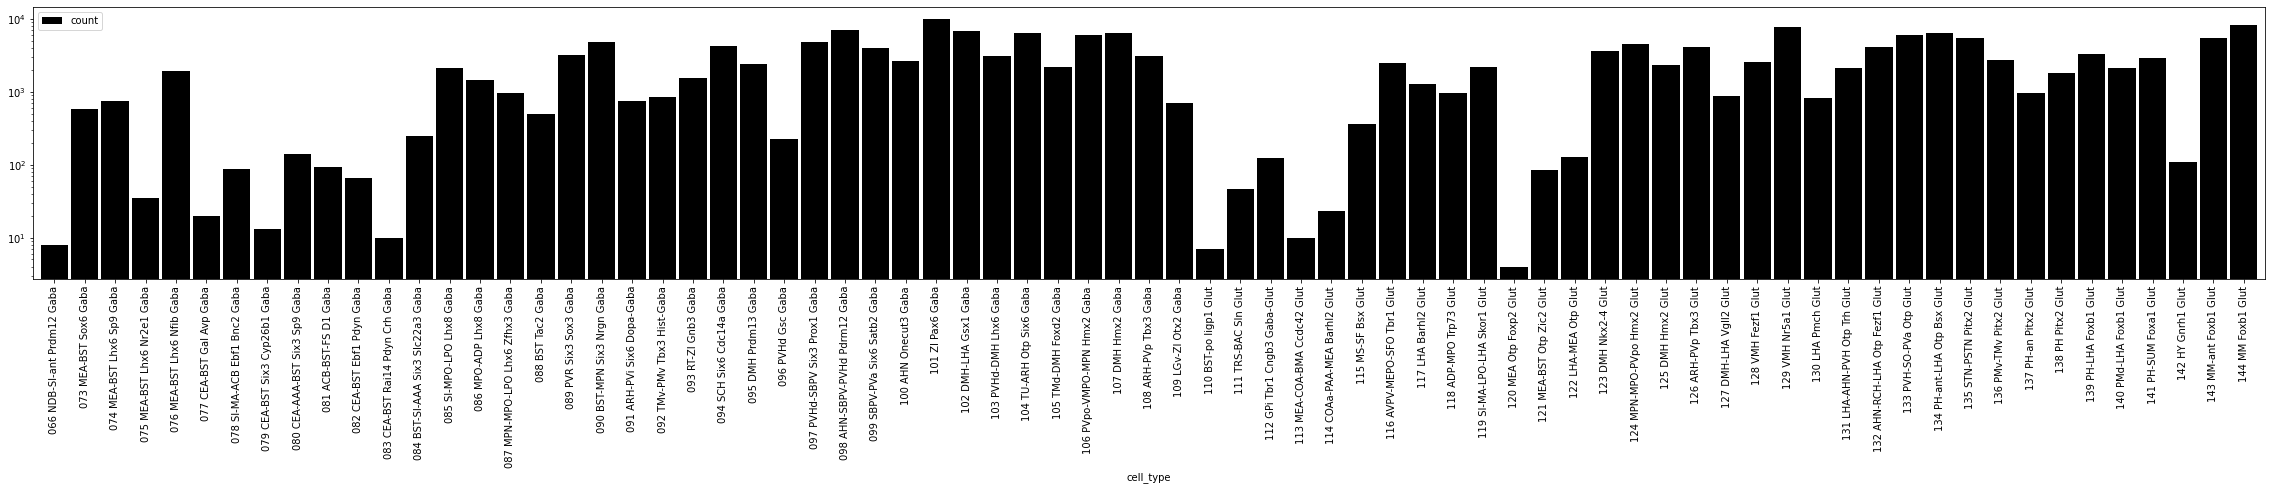

In [32]:
dfhypo.plot(kind='bar', x = 'cell_type',y='count', width = .9,color = 'black',figsize=(40,5))
plt.yscale('log')
plt.savefig('Figures/Figures_04102026/Numcells_CT_updated_04072026.png', bbox_inches = 'tight', dpi = 300)
plt.savefig('Figures/Figures_04102026/Numcells_CT_updated_04072026.svg')

In [34]:
df['fraction'] = df['count']/np.sum(df['count'])

In [36]:
df[df['cell_type'] == '095 DMH Prdm13 Gaba']

,Unnamed: 0,cell_type,count,fraction
29,29,095 DMH Prdm13 Gaba,2407,0.013146


In [37]:
df[df['cell_type'] == '096 PVHd Gsc Gaba']

,Unnamed: 0,cell_type,count,fraction
61,61,096 PVHd Gsc Gaba,224,0.001223


In [38]:
df[df['cell_type'] == '109 LGv-ZI Otx2 Gaba']

,Unnamed: 0,cell_type,count,fraction
51,51,109 LGv-ZI Otx2 Gaba,692,0.003779


In [39]:
df[df['cell_type'] == '110 BST-po Iigp1 Glut']

,Unnamed: 0,cell_type,count,fraction
117,117,110 BST-po Iigp1 Glut,7,0.000038


In [40]:
df[df['cell_type'] == '142 HY Gnrh1 Glut']

,Unnamed: 0,cell_type,count,fraction
69,69,142 HY Gnrh1 Glut,110,0.000601


In [41]:
df.to_csv('Allen_Institute_Numcells_RegionHY_04072026.csv')